# Análisis Exploratorio y Selección de Variables

En este notebook se realiza el análisis exploratorio del dataset maestro construido previamente.

Los objetivos son:

- Comprender la distribución de las variables.
- Analizar la variable objetivo.
- Detectar correlaciones.
- Identificar posibles problemas de multicolinealidad.
- Seleccionar las variables más relevantes para el entrenamiento de modelos de Machine Learning.

## 1. Importación de librerías

Se cargan las librerías necesarias para el análisis estadístico y visualización de datos.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del dataset

Se carga el dataset final generado en la fase de preparación de datos.

In [3]:
dataset = pd.read_csv(
    "dataset_mundial_final.csv"
)

## 3. Inspección inicial

Se verifica la estructura general del dataset.

In [4]:
dataset.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,goal_diff,tournament_weight,fifa_rank_home,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
0,2000-03-19,Cayman Islands,Cuba,0.0,0.0,FIFA World Cup qualification,False,0.0,6,149.0,...,1.0,-1.0,5.0,8.0,7.0,1.0,-4.0,-8.0,-6.0,-2.0
1,2000-03-19,Dominica,Haiti,1.0,3.0,FIFA World Cup qualification,False,-2.0,6,152.0,...,0.0,2.0,7.0,5.0,12.0,-7.0,-4.0,-3.0,-12.0,9.0
2,2000-03-19,Bermuda,British Virgin Islands,9.0,0.0,FIFA World Cup qualification,False,9.0,6,157.0,...,2.0,-2.0,3.0,4.0,8.0,-4.0,-3.0,-4.0,-6.0,2.0
3,2000-03-25,Bahrain,Jordan,1.0,1.0,Friendly,False,0.0,1,139.0,...,1.0,0.0,8.0,6.0,5.0,1.0,-5.0,-5.0,-4.0,-1.0
4,2000-03-25,Zambia,Botswana,3.0,0.0,COSAFA Cup,False,3.0,3,38.0,...,5.0,1.0,4.0,4.0,8.0,-4.0,2.0,2.0,-3.0,5.0


In [5]:
dataset.shape

(16704, 30)

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 16704 entries, 0 to 16703
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      16704 non-null  str    
 1   home_team                 16704 non-null  str    
 2   away_team                 16704 non-null  str    
 3   home_score                16704 non-null  float64
 4   away_score                16704 non-null  float64
 5   tournament                16704 non-null  str    
 6   neutral                   16704 non-null  bool   
 7   goal_diff                 16704 non-null  float64
 8   tournament_weight         16704 non-null  int64  
 9   fifa_rank_home            16704 non-null  float64
 10  fifa_points_home          16704 non-null  float64
 11  fifa_rank_away            16704 non-null  float64
 12  fifa_points_away          16704 non-null  float64
 13  elo_home                  16704 non-null  float64
 14  elo_away         

In [7]:
dataset.describe()

,home_score,away_score,goal_diff,tournament_weight,fifa_rank_home,fifa_points_home,fifa_rank_away,fifa_points_away,elo_home,elo_away,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
count,16704.000000,16704.000000,16704.000000,16704.000000,16704.00000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,...,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000
mean,1.552862,1.065074,0.487787,4.035740,78.75467,798.669767,82.061243,782.175307,1533.593511,1511.076269,...,5.254550,2.594289,5.432172,5.332854,7.804119,-2.471264,2.921157,2.515984,-2.549569,5.065553
std,1.515320,1.212852,2.100759,2.529189,52.93782,471.017738,52.899956,463.058723,284.500151,284.305987,...,3.303808,5.840542,3.334395,3.170005,4.300060,6.090922,4.523483,4.817658,5.041568,7.838928
min,0.000000,0.000000,-14.000000,1.000000,1.00000,0.000000,1.000000,0.000000,497.000000,497.000000,...,0.000000,-45.000000,0.000000,0.000000,0.000000,-42.000000,-14.000000,-22.000000,-38.000000,-38.000000
25%,0.000000,0.000000,-1.000000,1.000000,33.00000,405.000000,38.000000,399.000000,1342.750000,1330.000000,...,3.000000,-1.000000,3.000000,3.000000,5.000000,-6.000000,0.000000,-1.000000,-5.000000,0.000000
50%,1.000000,1.000000,0.000000,4.000000,73.00000,701.000000,77.000000,681.000000,1547.000000,1530.000000,...,5.000000,3.000000,5.000000,5.000000,7.000000,-2.000000,3.000000,2.000000,-2.000000,5.000000
75%,2.000000,2.000000,2.000000,6.000000,117.00000,1198.000000,120.000000,1174.992500,1734.000000,1712.000000,...,7.000000,6.000000,8.000000,7.000000,10.000000,1.000000,6.000000,5.000000,1.000000,10.000000
max,17.000000,14.000000,17.000000,10.000000,211.00000,2164.000000,211.000000,2164.000000,2167.000000,2167.000000,...,48.000000,36.000000,15.000000,27.000000,43.000000,25.000000,15.000000,33.000000,38.000000,59.000000


## 4. Verificación de valores faltantes

Se comprueba que el dataset no contiene valores nulos.

In [8]:
dataset.isna().sum()

date                        0
home_team                   0
away_team                   0
home_score                  0
away_score                  0
tournament                  0
neutral                     0
goal_diff                   0
tournament_weight           0
fifa_rank_home              0
fifa_points_home            0
fifa_rank_away              0
fifa_points_away            0
elo_home                    0
elo_away                    0
fifa_rank_diff              0
fifa_points_diff            0
elo_diff                    0
home_last5_points           0
home_last5_goals_for        0
home_last5_goals_against    0
home_last5_goal_balance     0
away_last5_points           0
away_last5_goals_for        0
away_last5_goals_against    0
away_last5_goal_balance     0
form_points_diff            0
form_goals_for_diff         0
form_goals_against_diff     0
form_goal_balance_diff      0
dtype: int64

## 5. Análisis de la variable objetivo

La variable objetivo del problema es la diferencia de goles.

Valores positivos indican victoria del equipo local.

Valores negativos indican victoria del equipo visitante.

El valor cero representa empate.

In [9]:
dataset["goal_diff"].describe()

count    16704.000000
mean         0.487787
std          2.100759
min        -14.000000
25%         -1.000000
50%          0.000000
75%          2.000000
max         17.000000
Name: goal_diff, dtype: float64

In [10]:
dataset["goal_diff"].value_counts().sort_index()

goal_diff
-14.0       1
-13.0       1
-11.0       1
-10.0       3
-9.0        2
-8.0       12
-7.0       19
-6.0       58
-5.0       87
-4.0      235
-3.0      597
-2.0     1279
-1.0     2468
 0.0     3998
 1.0     3510
 2.0     2135
 3.0     1147
 4.0      578
 5.0      285
 6.0      139
 7.0       78
 8.0       32
 9.0       15
 10.0      14
 11.0       2
 12.0       1
 13.0       2
 14.0       3
 15.0       1
 17.0       1
Name: count, dtype: int64

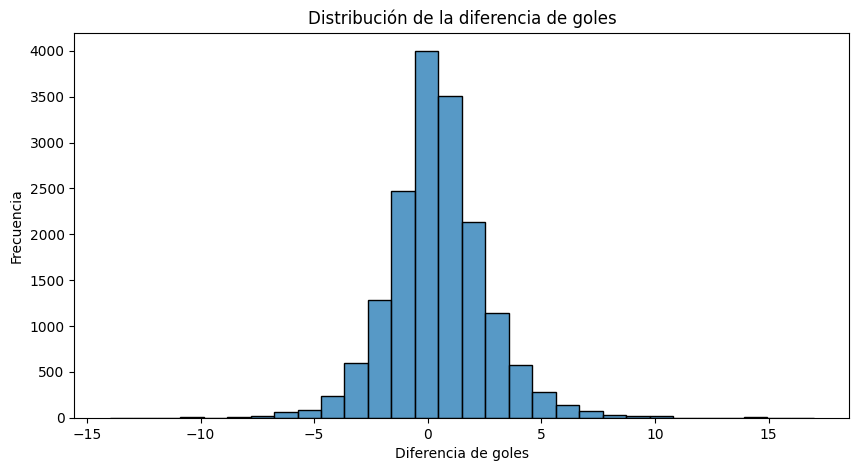

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataset["goal_diff"],
    bins=30
)

plt.title("Distribución de la diferencia de goles")
plt.xlabel("Diferencia de goles")
plt.ylabel("Frecuencia")

plt.savefig(
    "histograma_goal_diff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

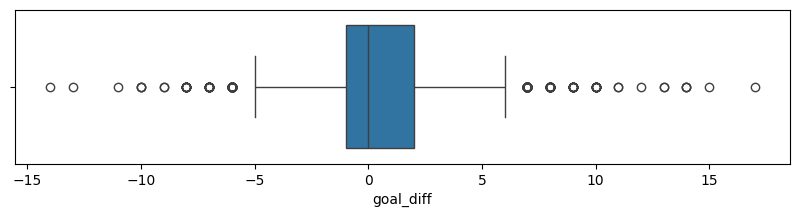

In [12]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=dataset["goal_diff"]
)

plt.show()

## Conclusiones preliminares

El dataset final contiene 16.704 partidos internacionales disputados entre 2000 y 2025.

No existen valores faltantes y todas las variables necesarias para el modelado están disponibles.

Se ha realizado una primera inspección de la variable objetivo (goal_diff), observándose una distribución centrada en valores próximos al empate, con presencia de algunas goleadas extremas menos frecuentes.

El análisis detallado de correlaciones y selección de variables se realizará en las siguientes fases del proyecto.

# 4. Variables numéricas

In [13]:
numeric_cols = dataset.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['home_score', 'away_score', 'goal_diff', 'tournament_weight',
       'fifa_rank_home', 'fifa_points_home', 'fifa_rank_away',
       'fifa_points_away', 'elo_home', 'elo_away', 'fifa_rank_diff',
       'fifa_points_diff', 'elo_diff', 'home_last5_points',
       'home_last5_goals_for', 'home_last5_goals_against',
       'home_last5_goal_balance', 'away_last5_points', 'away_last5_goals_for',
       'away_last5_goals_against', 'away_last5_goal_balance',
       'form_points_diff', 'form_goals_for_diff', 'form_goals_against_diff',
       'form_goal_balance_diff'],
      dtype='str')

## Correlación entre variables

Se estudian las relaciones lineales entre las variables numéricas para detectar redundancias y posibles problemas de multicolinealidad.

In [14]:
corr = dataset[numeric_cols].corr()

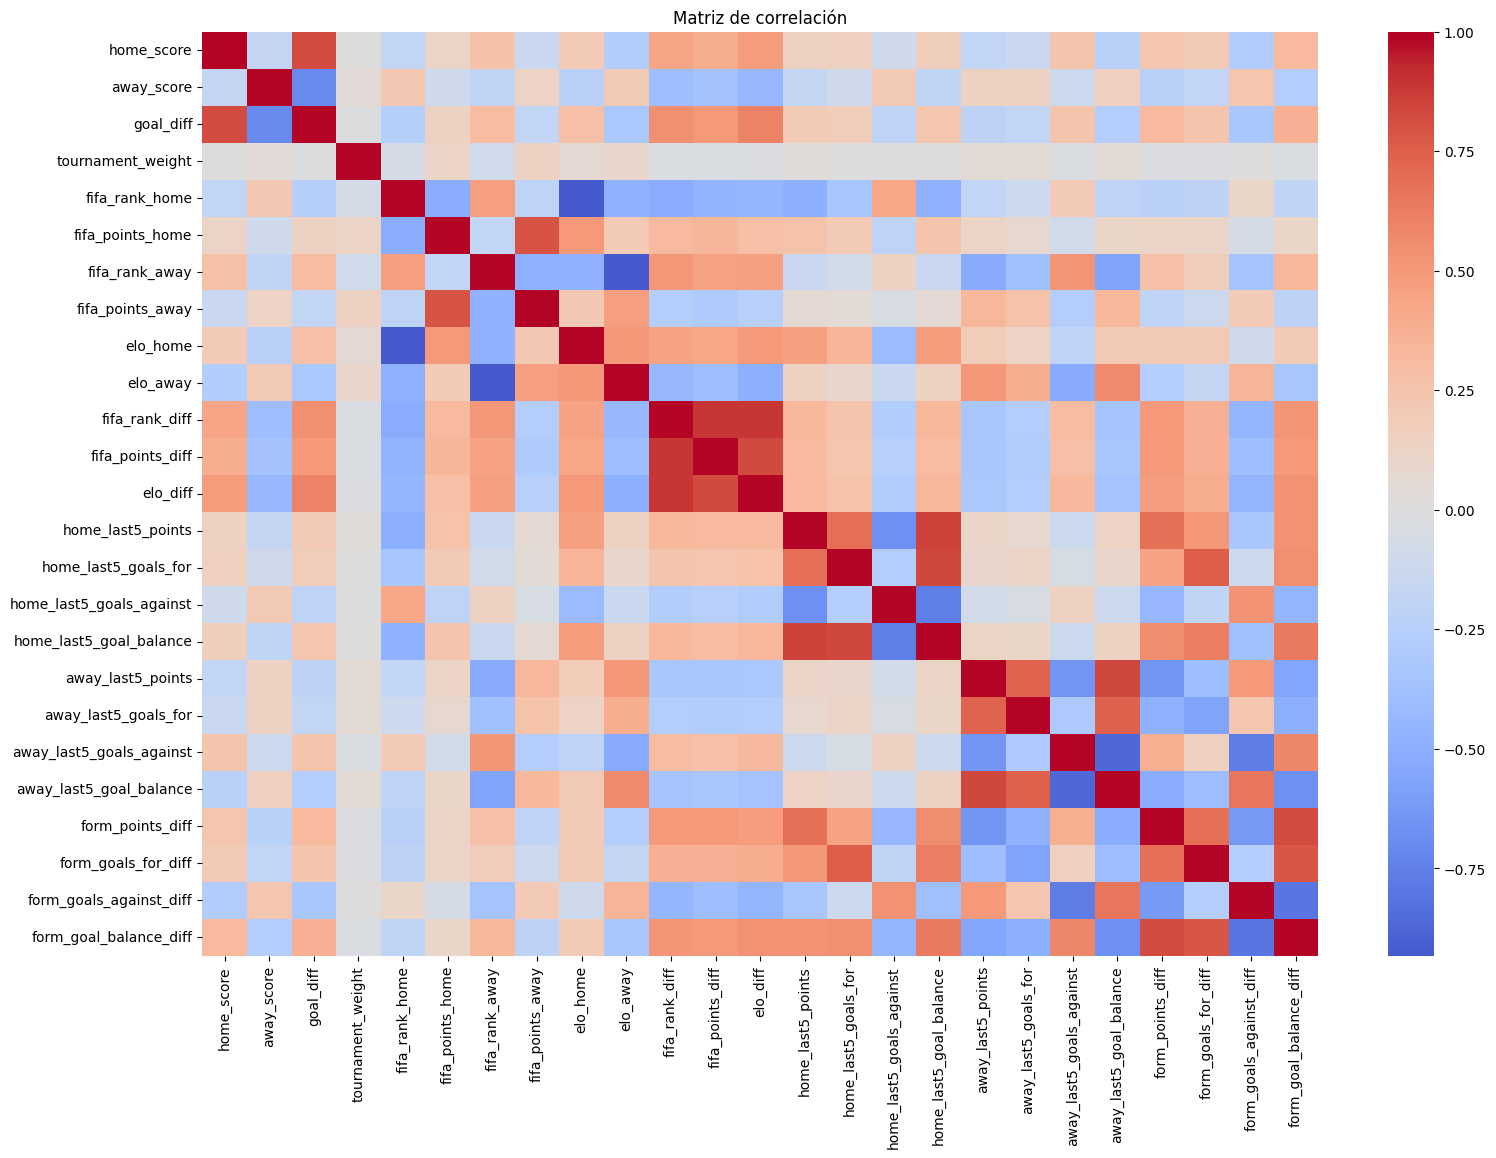

In [15]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

In [16]:
corr_goal = (
    corr["goal_diff"]
    .sort_values(ascending=False)
)

corr_goal

goal_diff                   1.000000
home_score                  0.822784
elo_diff                    0.605641
fifa_rank_diff              0.547476
fifa_points_diff            0.497095
form_goal_balance_diff      0.380378
form_points_diff            0.313540
fifa_rank_away              0.305669
elo_home                    0.279325
form_goals_for_diff         0.259353
away_last5_goals_against    0.248210
home_last5_goal_balance     0.231239
home_last5_points           0.203039
home_last5_goals_for        0.171506
fifa_points_home            0.145260
tournament_weight          -0.009907
away_last5_goals_for       -0.177881
fifa_points_away           -0.178311
home_last5_goals_against   -0.201273
away_last5_points          -0.215395
fifa_rank_home             -0.258352
away_last5_goal_balance    -0.267808
elo_away                   -0.325179
form_goals_against_diff    -0.343600
away_score                 -0.704108
Name: goal_diff, dtype: float64

In [17]:
dataset["neutral"] = dataset["neutral"].astype(int)

In [19]:
corr = dataset.corr(numeric_only=True)
corr

,home_score,away_score,neutral,goal_diff,tournament_weight,fifa_rank_home,fifa_points_home,fifa_rank_away,fifa_points_away,elo_home,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
home_score,1.000000,-0.175745,-0.079844,0.822784,0.015574,-0.180273,0.114407,0.270103,-0.143123,0.201017,...,-0.107734,0.165145,-0.182240,-0.132536,0.250174,-0.245595,0.240998,0.213536,-0.283978,0.313874
away_score,-0.175745,1.000000,0.074836,-0.704108,0.036617,0.222256,-0.108665,-0.191981,0.130034,-0.232666,...,0.214021,-0.194195,0.145394,0.142516,-0.117356,0.157023,-0.241977,-0.182432,0.240346,-0.266697
neutral,-0.079844,0.074836,1.000000,-0.100799,0.035033,0.009440,0.051765,0.013472,0.041553,-0.010613,...,-0.033883,0.024071,0.035934,0.012665,-0.037251,0.032890,0.005083,-0.002389,0.009568,-0.007622
goal_diff,0.822784,-0.704108,-0.100799,1.000000,-0.009907,-0.258352,0.145260,0.305669,-0.178311,0.279325,...,-0.201273,0.231239,-0.215395,-0.177881,0.248210,-0.267808,0.313540,0.259353,-0.343600,0.380378
tournament_weight,0.015574,0.036617,0.035033,-0.009907,1.000000,-0.067363,0.122548,-0.101836,0.142308,0.062433,...,-0.009536,0.011511,0.055679,0.051795,-0.028356,0.046976,-0.023564,-0.026666,0.017936,-0.027924
fifa_rank_home,-0.180273,0.222256,0.009440,-0.258352,-0.067363,1.000000,-0.507678,0.469355,-0.207240,-0.932616,...,0.431507,-0.479621,-0.183633,-0.111276,0.204436,-0.202241,-0.236791,-0.212320,0.108405,-0.200208
fifa_points_home,0.114407,-0.108665,0.051765,0.145260,0.122548,-0.507678,1.000000,-0.184573,0.788647,0.494246,...,-0.207740,0.255024,0.116803,0.077672,-0.091745,0.105194,0.114329,0.115602,-0.057883,0.108274
fifa_rank_away,0.270103,-0.191981,0.013472,0.305669,-0.101836,0.469355,-0.184573,1.000000,-0.480192,-0.472513,...,0.134238,-0.137855,-0.526455,-0.383060,0.524109,-0.569372,0.278312,0.176985,-0.359055,0.339697
fifa_points_away,-0.143123,0.130034,0.041553,-0.178311,0.142308,-0.207240,0.788647,-0.480192,1.000000,0.220678,...,-0.045580,0.058361,0.342241,0.260547,-0.274810,0.329611,-0.206289,-0.131944,0.204522,-0.212628
elo_home,0.201017,-0.232666,-0.010613,0.279325,0.062433,-0.932616,0.494246,-0.472513,0.220678,1.000000,...,-0.422694,0.482624,0.190212,0.129072,-0.201549,0.209464,0.209927,0.210295,-0.105092,0.196833


# Conclusiones del análisis exploratorio

Tras el análisis estadístico y de correlación se observa que:

- Las variables derivadas de Elo presentan la mayor relación con la diferencia de goles.
- Las variables FIFA también aportan información relevante.
- Las métricas de forma reciente muestran capacidad predictiva adicional.
- Existen relaciones de correlación entre algunas variables, aunque la selección definitiva se realizará durante la fase de entrenamiento.

El dataset queda preparado para la construcción de modelos predictivos.

## Variables disponibles antes del partido

Se eliminan aquellas variables que contienen información del resultado final del encuentro y que, por tanto, no estarían disponibles en el momento de realizar una predicción.

In [ ]:
variables_modelo = [
    "tournament_weight",
    "neutral",

    "fifa_rank_home",
    "fifa_points_home",
    "fifa_rank_away",
    "fifa_points_away",

    "elo_home",
    "elo_away",

    "fifa_rank_diff",
    "fifa_points_diff",
    "elo_diff",

    "home_last5_points",
    "home_last5_goals_for",
    "home_last5_goals_against",
    "home_last5_goal_balance",

    "away_last5_points",
    "away_last5_goals_for",
    "away_last5_goals_against",
    "away_last5_goal_balance",

    "form_points_diff",
    "form_goals_for_diff",
    "form_goals_against_diff",
    "form_goal_balance_diff"
]

target = "goal_diff"

In [20]:
dataset.to_csv(
    "dataset_modelado.csv",
    index=False
)